[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/takechanman1228/marketing-science-in-python/blob/main/notebooks/part6-media-optimization/sec6.2_mmm_end_to_end_demo.ipynb)

# Marketing Mix Modeling: End-to-End Demo with Meridian

**Companion notebook for Chapter 6.2 (Fundamentals) and Chapter 6.3 (Calibration) of *Marketing Science: A Practitioner's Guide*.**

This notebook walks through a complete MMM workflow using Google's [Meridian](https://github.com/google/meridian) library on **synthetic data generated by [PySiMMMulator](https://github.com/leehananne/PySiMMMulator)** (see `mmm_data_generation.py`).

1. **Install / import** — bring in TensorFlow, TFP, and Meridian
2. **Data loading** — load synthetic marketing data with known ground-truth ROI
2b. **Data identifiability check** — §6.3 Reliability Checklist applied pre-fit
3. **Build Meridian InputData** — exposure volumes drive saturation, spend drives ROI
4. **Holdout split** — random 25% of weeks for out-of-sample evaluation
5. **Model configuration** — weakly informative ROI prior + funnel-stage adstock/EC
6. **Model training** — Bayesian MMM with adstock and saturation via MCMC (NUTS)
7. **Diagnostics** — convergence checks and prior/posterior shift
8. **Model fit** — in-sample R² and out-of-sample R² from the holdout
9. **Media insights** — ROI, contribution, and response curves
10. **Ground-truth comparison** — compare estimated ROI against the known true values
11. **Budget optimization** — optimal allocation given a fixed total budget
12. **Reallocation table** — channel-level spend deltas the optimizer recommends
13. **Credible interval guardrail** — convert posterior uncertainty into act/hold per channel
14. **Geo-lift → calibrated prior** — show how a §6.3-style DID estimate plugs back into `roi_m`
15. **Refit with calibrated prior** — apply the calibration and resample
16. **Before / after ROI** — does calibration close the recovery gap for the calibrated channel?
17. **Re-optimize from calibrated model** — does the budget recommendation change?
18. **Scope and limitations** — what this demo proves and what it does not
19. **Persistence** — save both fitted models

Because we use synthetic data with **known ground-truth ROI**, we can validate that Meridian's estimates recover the true channel-level effects — something impossible with real-world observational data.

> **Important:** Meridian applies Hill saturation to `media_cols` (impressions/clicks), not to spend. This correctly models diminishing returns on *exposure volume* while keeping spend as a cost metric for ROI calculation.

## Step 1: Install and Import

Meridian is built on TensorFlow and TensorFlow Probability. The local `marketing-science` conda environment pins all three; in Colab, install `google-meridian` before running.

In [1]:
# Dependencies are managed by My Book/environment.yml.
# In Colab, install google-meridian before running this notebook.
import importlib.util

required_modules = ["tensorflow", "tensorflow_probability", "meridian"]
missing = [name for name in required_modules if importlib.util.find_spec(name) is None]
if missing:
    raise RuntimeError(
        "Missing MMM dependencies: " + ", ".join(missing)
        + ". Update the marketing-science environment from environment.yml."
    )
print("MMM dependencies available.")

MMM dependencies available.


In [2]:
# Colab bootstrap: make the `msbook` helper package importable.
# Local / conda users already have it via `pip install -e .` from the repo root,
# so this is a no-op for them. On Colab it clones the book repo and installs
# msbook in editable mode. (A plain `pip install git+...` is not enough: msbook
# resolves paths by walking up to the repo's _quarto.yml, so it needs the repo
# tree present, which the clone provides.)
import sys
try:
    import msbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess
    _REPO = "https://github.com/takechanman1228/marketing-science-in-python.git"
    subprocess.run(["git", "clone", "-q", _REPO], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e",
                    "marketing-science-in-python"], check=True)
    import msbook  # noqa: F401

import warnings

# Keep Meridian/numpy advisory warnings out of the published outputs — they
# print absolute site-packages paths (tripping the release leak scan) and add
# noise for readers.
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_probability as tfp

# Disable TF32 on Ampere+ GPUs to improve MCMC numerical stability.
tf.config.experimental.enable_tensor_float_32_execution(False)

from meridian import constants
from meridian.data import data_frame_input_data_builder
from meridian.model import model
from meridian.model import spec
from meridian.model import prior_distribution
from meridian.analysis import optimizer
from meridian.analysis import summarizer
from meridian.analysis import visualizer
from meridian.analysis.review import reviewer

In [3]:
# Static figures for the published notebook: GitHub renders .ipynb without
# executing JavaScript, so Meridian's interactive Altair charts would be
# invisible there. When this notebook is re-executed locally / in CI, render
# Altair output as static PNGs (via vl-convert) so the committed outputs show
# on GitHub. On Colab, keep the default interactive renderer.
import importlib.util

if "google.colab" not in sys.modules and importlib.util.find_spec("vl_convert"):
    import altair as alt

    alt.renderers.enable("png", scale_factor=2)

## Step 2: Load Synthetic Data

The synthetic data was generated by `mmm_data_generation.py` using PySiMMMulator. The CSV contains both **exposure volumes** (impressions for TV/CTV, OOH, Meta, TikTok; clicks for Google Search) and **spend** for each channel, along with control variables.

In [4]:
# Paths are resolved by the in-repo `msbook` package (installed via
# `pip install -e .` from the repo root — see README), so this works from
# any cwd or notebook subdirectory.
from msbook.data import load_mmm_synthetic
from msbook.paths import DATA_DIR

df = load_mmm_synthetic()
truth_df = pd.read_csv(DATA_DIR / "generated" / "part6" / "sec6.2-mmm" / "mmm_ground_truth_roi.csv")

print(f"Dataset shape: {df.shape}")
print(f"Period: {df['time'].min()} to {df['time'].max()}")
print()
print("Ground-truth ROI per channel:")
print(truth_df.to_string(index=False))
df.head()

Dataset shape: (157, 19)
Period: 2020-12-28 to 2023-12-25

Ground-truth ROI per channel:
      channel  true_roi
       TV/CTV    4.1689
          OOH    6.2764
Google Search    0.1773
         Meta    3.7446
       TikTok    3.0056


,time,geo,tv_ctv_impressions,ooh_impressions,meta_impressions,tiktok_impressions,google_clicks,tv_ctv_spend,ooh_spend,meta_spend,tiktok_spend,google_spend,sales,seas_sin52,seas_cos52,hldy_thanksgiving,hldy_christmas,trend,trend_sq
0,2020-12-28,national,2.386109e+07,0.0,9.164925e+07,5.281467e+07,112560.022813,280723.950241,0.0,6.969747e+05,295662.003726,278758.871768,3.471585e+07,-0.038696,0.999251,0,1,0.0,0.0
1,2021-01-04,national,5.603806e+07,0.0,1.761449e+08,1.210556e+08,229435.025708,661180.426472,0.0,1.405250e+06,697357.227534,576814.027939,8.287763e+07,0.068755,0.997634,0,0,1.0,1.0
2,2021-01-11,national,5.315006e+07,0.0,1.620106e+08,1.135982e+08,277525.215213,639516.995585,0.0,1.215721e+06,582311.328388,644509.434814,8.335021e+07,0.188099,0.982150,0,0,2.0,4.0
3,2021-01-18,national,4.750385e+07,0.0,1.539666e+08,1.041100e+08,264721.279702,591691.550121,0.0,1.222140e+06,642675.919865,642807.289028,8.293286e+07,0.304719,0.952442,0,0,3.0,9.0
4,2021-01-25,national,4.833465e+07,0.0,1.673655e+08,9.401605e+07,239042.672518,558524.426061,0.0,1.266757e+06,568506.383139,630916.809915,8.362783e+07,0.416926,0.908940,0,0,4.0,16.0


## Step 2b: Data Identifiability Check

Before fitting, Section 6.3's *Reliability Checklist* asks for three pre-fit diagnostics:

1. **Enough history** — at least ~80 weekly observations so adstock and saturation are estimable.
2. **Real variation in spend** — channels with constant weekly spend give the model no signal.
3. **Correlated media flights** — when channels move in lockstep, the model can't separate their effects.

A practitioner would walk away from any MMM whose data fails these checks. We compute the same three things here on the demo dataset; the thresholds match `mmm_data_generation.py`'s identifiability QC so a passing run here means the synthetic data is in the regime where MMM has a fair chance.

In [5]:
spend_cols = ["tv_ctv_spend", "ooh_spend", "google_spend", "meta_spend", "tiktok_spend"]
spend_df = df[spend_cols].copy()
spend_df.columns = ["TV/CTV", "OOH", "Google Search", "Meta", "TikTok"]

# (1) History length.
n_weeks = len(df)
print(f"(1) History: {n_weeks} weekly observations "
      f"({'PASS' if n_weeks >= 80 else 'FAIL'} — need ≥ 80)")

# (2) Spend variation: share-of-budget standard deviation per channel during weeks the channel was on.
total_spend = spend_df.sum(axis=1).replace(0, np.nan)
shares = spend_df.div(total_spend, axis=0).fillna(0)
share_std = {col: float(shares[col][spend_df[col] > 0].std()) for col in spend_df.columns}
off_rate = {col: float((spend_df[col] == 0).mean()) for col in spend_df.columns}

variation = pd.DataFrame({
    "OFF rate (weeks off)":  off_rate,
    "Share std (when on)":   share_std,
})
print()
print("(2) Per-channel spend variation:")
print(variation.to_string(float_format=lambda x: f"{x:.3f}"))
worst_off_rate = max(off_rate.values())
worst_share_std = min(share_std.values())
print(f"  Worst OFF rate (high is bad past ~25%): {worst_off_rate:.1%} — "
      f"{'PASS' if worst_off_rate <= 0.25 else 'WARN'}")
print(f"  Lowest share std (low = no variation): {worst_share_std:.3f} — "
      f"{'PASS' if worst_share_std >= 0.05 else 'WARN'}")

# (3) Channel correlation matrix.
corr = spend_df.corr().abs()
# Diagonal is 1.0; look at off-diagonal maximum.
np.fill_diagonal(corr.values, 0.0)
print()
print("(3) Absolute channel-spend correlation matrix:")
print(corr.to_string(float_format=lambda x: f"{x:.2f}"))
max_corr = float(corr.values.max())
print(f"  Max off-diagonal |corr| (high = collinearity risk past ~0.85): {max_corr:.2f} — "
      f"{'PASS' if max_corr <= 0.85 else 'FAIL'}")

(1) History: 157 weekly observations (PASS — need ≥ 80)

(2) Per-channel spend variation:
               OFF rate (weeks off)  Share std (when on)
TV/CTV                        0.070                0.061
OOH                           0.102                0.085
Google Search                 0.127                0.083
Meta                          0.178                0.088
TikTok                        0.051                0.088
  Worst OFF rate (high is bad past ~25%): 17.8% — PASS
  Lowest share std (low = no variation): 0.061 — PASS

(3) Absolute channel-spend correlation matrix:
               TV/CTV  OOH  Google Search  Meta  TikTok
TV/CTV           0.00 0.12           0.02  0.07    0.32
OOH              0.12 0.00           0.04  0.21    0.14
Google Search    0.02 0.04           0.00  0.33    0.29
Meta             0.07 0.21           0.33  0.00    0.61
TikTok           0.32 0.14           0.29  0.61    0.00
  Max off-diagonal |corr| (high = collinearity risk past ~0.85): 0.61 — PAS

## Step 3: Build Meridian InputData

Meridian separates exposure volume from spend. `media_cols` (impressions/clicks) drive the Hill saturation curve; `media_spend_cols` is the cost basis for ROI. Controls handle seasonality, holidays, and trend.

In [6]:
channels = ["TV/CTV", "OOH", "Google Search", "Meta", "TikTok"]

media_cols = [
    "tv_ctv_impressions", "ooh_impressions", "google_clicks",
    "meta_impressions", "tiktok_impressions",
]
media_spend_cols = [
    "tv_ctv_spend", "ooh_spend", "google_spend",
    "meta_spend", "tiktok_spend",
]
control_cols = [
    "seas_sin52", "seas_cos52",
    "hldy_thanksgiving", "hldy_christmas",
    "trend", "trend_sq",
]

assert len(media_cols) == len(media_spend_cols) == len(channels), "List length mismatch"

builder = data_frame_input_data_builder.DataFrameInputDataBuilder(
    kpi_type="revenue",
    default_kpi_column="sales",
    default_time_column="time",
    default_geo_column="geo",
)
data = (
    builder
    .with_kpi(df)
    .with_media(df, media_cols=media_cols, media_spend_cols=media_spend_cols, media_channels=channels)
    .with_controls(df, control_cols=control_cols)
    .build()
)

## Step 4: Holdout Split for Out-of-Sample Validation

A strong in-sample fit on its own is not evidence that the model generalizes. We mark 25% of weeks as **holdout** — Meridian keeps the media in those weeks (so adstock carry-over is preserved) but excludes the KPI from the training likelihood. `predictive_accuracy_table()` will then report Train and Test R² separately.

We use a **random week-level sample** rather than a trailing block. With trend + seasonality, a trailing-block holdout asks the model to extrapolate beyond its training window, which dramatically depresses out-of-sample R² for reasons that have nothing to do with media measurement. A random week-level holdout interleaves train and test weeks so out-of-sample R² reflects the model's ability to interpolate within the observed regime — the more useful generalization check for MMM.

For a national model `holdout_id` is a 1-D boolean array of shape `(n_times,)`. For a geo-level model it is `(n_geos, n_times)`.

In [7]:
n_times = df["time"].nunique()
holdout_frac = 0.25
n_holdout = int(round(n_times * holdout_frac))

rng = np.random.default_rng(20260520)  # deterministic
holdout_idx = rng.choice(n_times, size=n_holdout, replace=False)
holdout_id = np.zeros(n_times, dtype=bool)
holdout_id[holdout_idx] = True

print(f"Total weeks: {n_times}")
print(f"Train weeks: {n_times - n_holdout}  ({1 - holdout_frac:.0%})")
print(f"Test  weeks: {n_holdout}  ({holdout_frac:.0%})")
print(f"Test weeks span: indices {holdout_idx.min()} to {holdout_idx.max()}  (random scatter)")

Total weeks: 157
Train weeks: 118  (75%)
Test  weeks: 39  (25%)
Test weeks span: indices 3 to 155  (random scatter)


## Step 5: Model Configuration with Weakly Informative ROI Prior

Meridian separates model specification into two components:

- **PriorDistribution** — prior beliefs about parameters (ROI, adstock decay, saturation)
- **ModelSpec** — structural choices (max lag, prior type, adstock form)

We use a **weakly informative ROI prior** for every channel: `roi_m ~ LogNormal(0.2, 0.9)`. This matches the structure Section 6.3 of the book uses for uncalibrated channels (median ROAS ≈ 1.2, 90% prior interval ≈ 0.28–5.4) — only channels with experimental evidence (e.g. a geo-lift result) get a tighter, channel-specific prior in production.

For **adstock decay (`alpha_m`)** and **saturation EC (`ec_m`)**, however, we *do* encode channel-specific expectations by funnel stage. These two parameters interact with ROI in subtle ways: without sensible centers for them, the sampler can find high-R² fits in which an inflated adstock decay or pushed-out saturation EC compensates for an over-estimated ROI. Anchoring `alpha_m` and `ec_m` to plausible business values is what keeps recovered ROIs honest, even when the ROI prior itself is wide.

| Funnel | Channels | Adstock | Adstock half-life | EC center |
|--------|----------|---------|-------------------|-----------|
| Upper  | TV/CTV, OOH | Binomial | 6 weeks | 1.3 |
| Mid    | Meta, TikTok | Geometric | 3 weeks | 0.95 |
| Lower  | Google Search | Geometric | 1 week | 0.6 |

A commented purely-ROI-prior block at the end of the cell shows the §6.3-style code if you want to skip the `alpha_m` / `ec_m` constraints; expect the resulting ROIs to be 2–3× inflated on this dataset.

In [8]:
DTYPE = tf.float32

channel_funnel = {
    "TV/CTV": "upper",
    "OOH": "upper",
    "Google Search": "lower",
    "Meta": "mid",
    "TikTok": "mid",
}

half_life_weeks = {"upper": 6,   "mid": 3,    "lower": 1}
ec_center       = {"upper": 1.3, "mid": 0.95, "lower": 0.6}

alpha_loc = tf.constant(
    [0.5 ** (1.0 / half_life_weeks[channel_funnel[ch]]) for ch in channels],
    dtype=DTYPE,
)
ec_loc = tf.constant(
    [ec_center[channel_funnel[ch]] for ch in channels],
    dtype=DTYPE,
)

prior = prior_distribution.PriorDistribution(
    # Weakly informative ROI prior — same as §6.3 uncalibrated channels.
    roi_m=tfp.distributions.LogNormal(
        loc=tf.constant(0.2, dtype=DTYPE),
        scale=tf.constant(0.9, dtype=DTYPE),
        name=constants.ROI_M,
    ),
    # Funnel-stage centers for adstock decay (taming the alpha/ROI tradeoff).
    alpha_m=tfp.distributions.TruncatedNormal(
        loc=alpha_loc,
        scale=tf.constant(0.1, dtype=DTYPE),
        low=tf.constant(0.0, dtype=DTYPE),
        high=tf.constant(1.0, dtype=DTYPE),
        name=constants.ALPHA_M,
    ),
    # Funnel-stage centers for saturation EC.
    ec_m=tfp.distributions.TruncatedNormal(
        loc=ec_loc,
        scale=tf.constant(0.3, dtype=DTYPE),
        low=tf.constant(0.05, dtype=DTYPE),
        high=tf.constant(6.0, dtype=DTYPE),
        name=constants.EC_M,
    ),
)

model_spec = spec.ModelSpec(
    prior=prior,
    media_prior_type="roi",
    max_lag=12,
    adstock_decay_spec={"TV/CTV": "binomial", "OOH": "binomial"},
    holdout_id=holdout_id,
)

print("Active prior:")
print("  roi_m   : LogNormal(loc=0.20, scale=0.90)   [weakly informative, all channels]")
print(f"  alpha_m : TruncatedNormal centered on funnel-stage half-lives "
      f"({alpha_loc.numpy().round(2).tolist()})")
print(f"  ec_m    : TruncatedNormal centered on funnel-stage EC "
      f"({ec_loc.numpy().tolist()})")
print(f"Prior ROAS median = {np.exp(0.2):.2f}; "
      f"90% interval ≈ [{np.exp(0.2 - 1.645*0.9):.2f}, "
      f"{np.exp(0.2 + 1.645*0.9):.2f}]")

# ---- Alternative: pure ROI-only weakly informative prior (commented). --------
# Uncomment to drop the alpha_m / ec_m constraints. On this dataset, expect
# recovered ROIs to be inflated by ~2-3x compared to the PySiMMMulator truth,
# even though in-sample R² stays near 0.96.
#
# prior = prior_distribution.PriorDistribution(
#     roi_m=tfp.distributions.LogNormal(
#         loc=tf.constant(0.2, dtype=DTYPE),
#         scale=tf.constant(0.9, dtype=DTYPE),
#         name=constants.ROI_M,
#     ),
# )

Active prior:
  roi_m   : LogNormal(loc=0.20, scale=0.90)   [weakly informative, all channels]
  alpha_m : TruncatedNormal centered on funnel-stage half-lives ([0.8899999856948853, 0.8899999856948853, 0.5, 0.7900000214576721, 0.7900000214576721])
  ec_m    : TruncatedNormal centered on funnel-stage EC ([1.2999999523162842, 1.2999999523162842, 0.6000000238418579, 0.949999988079071, 0.949999988079071])
Prior ROAS median = 1.22; 90% interval ≈ [0.28, 5.37]


## Step 6: Model Training

Meridian fits the model via MCMC using the No-U-Turn Sampler (NUTS). For CPU execution we keep the budget modest — 4 chains × 1,000 kept samples = 4,000 posterior draws — which is enough to assess R-hat and recover ROI signs on this 157-week dataset. Production runs typically use 10 chains × 2,000 keep.

We first draw from the prior (for prior predictive checks), then sample the posterior.

In [9]:
SEED = 105

mmm = model.Meridian(input_data=data, model_spec=model_spec)

# Prior predictive check
mmm.sample_prior(500)

# Posterior sampling via NUTS MCMC
mmm.sample_posterior(
    n_chains=4,
    n_adapt=500,
    n_burnin=500,
    n_keep=1000,
    seed=SEED,
)

I0000 00:00:1781147299.904549 40419683 service.cc:152] XLA service 0x600000bd2700 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781147299.904567 40419683 service.cc:160]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1781147299.940472 40419683 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2026-06-10 23:08:45.543647: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


## Step 7: Diagnostics

`ModelReviewer` runs the full battery (convergence, baseline validation, goodness of fit, prior-posterior shift). `ModelDiagnostics` produces the per-parameter R-hat plot — values should be close to 1.0.

In [10]:
# Automated model quality checks
review_summary = reviewer.ModelReviewer(mmm).run()
print(review_summary.summary_message)

Passed: No major quality issues were identified.


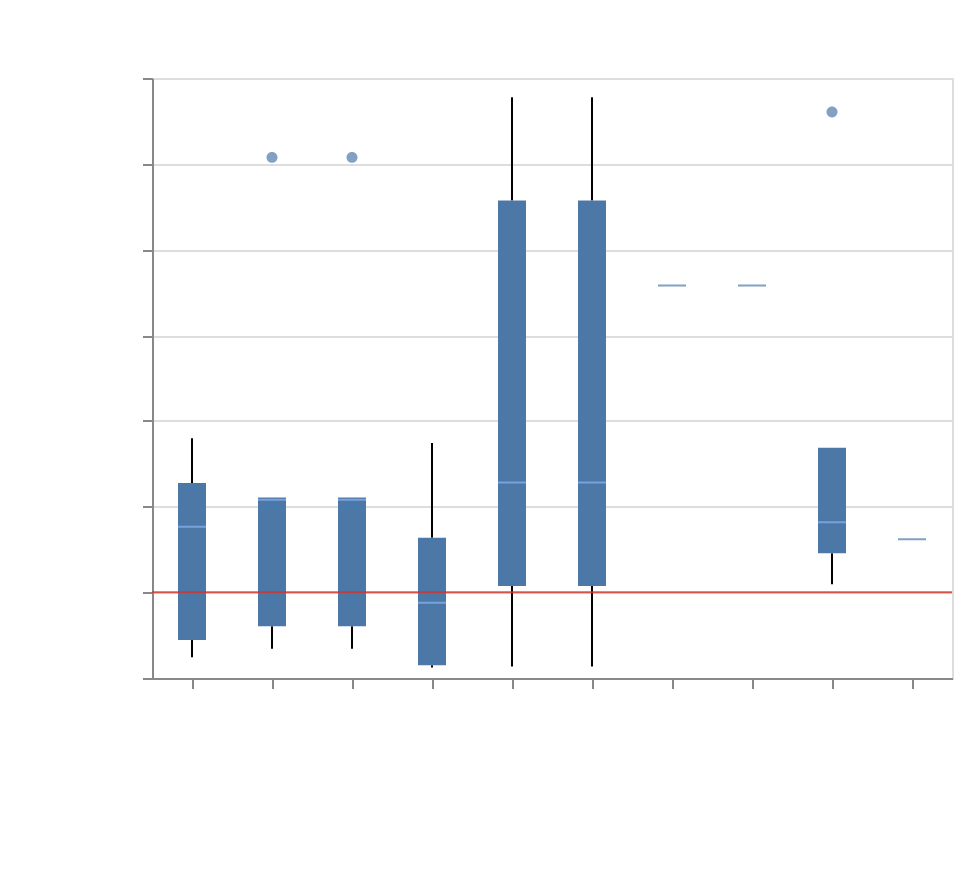

In [11]:
# R-hat values should be close to 1.0 for all parameters
diagnostics = visualizer.ModelDiagnostics(mmm)
diagnostics.plot_rhat_boxplot()

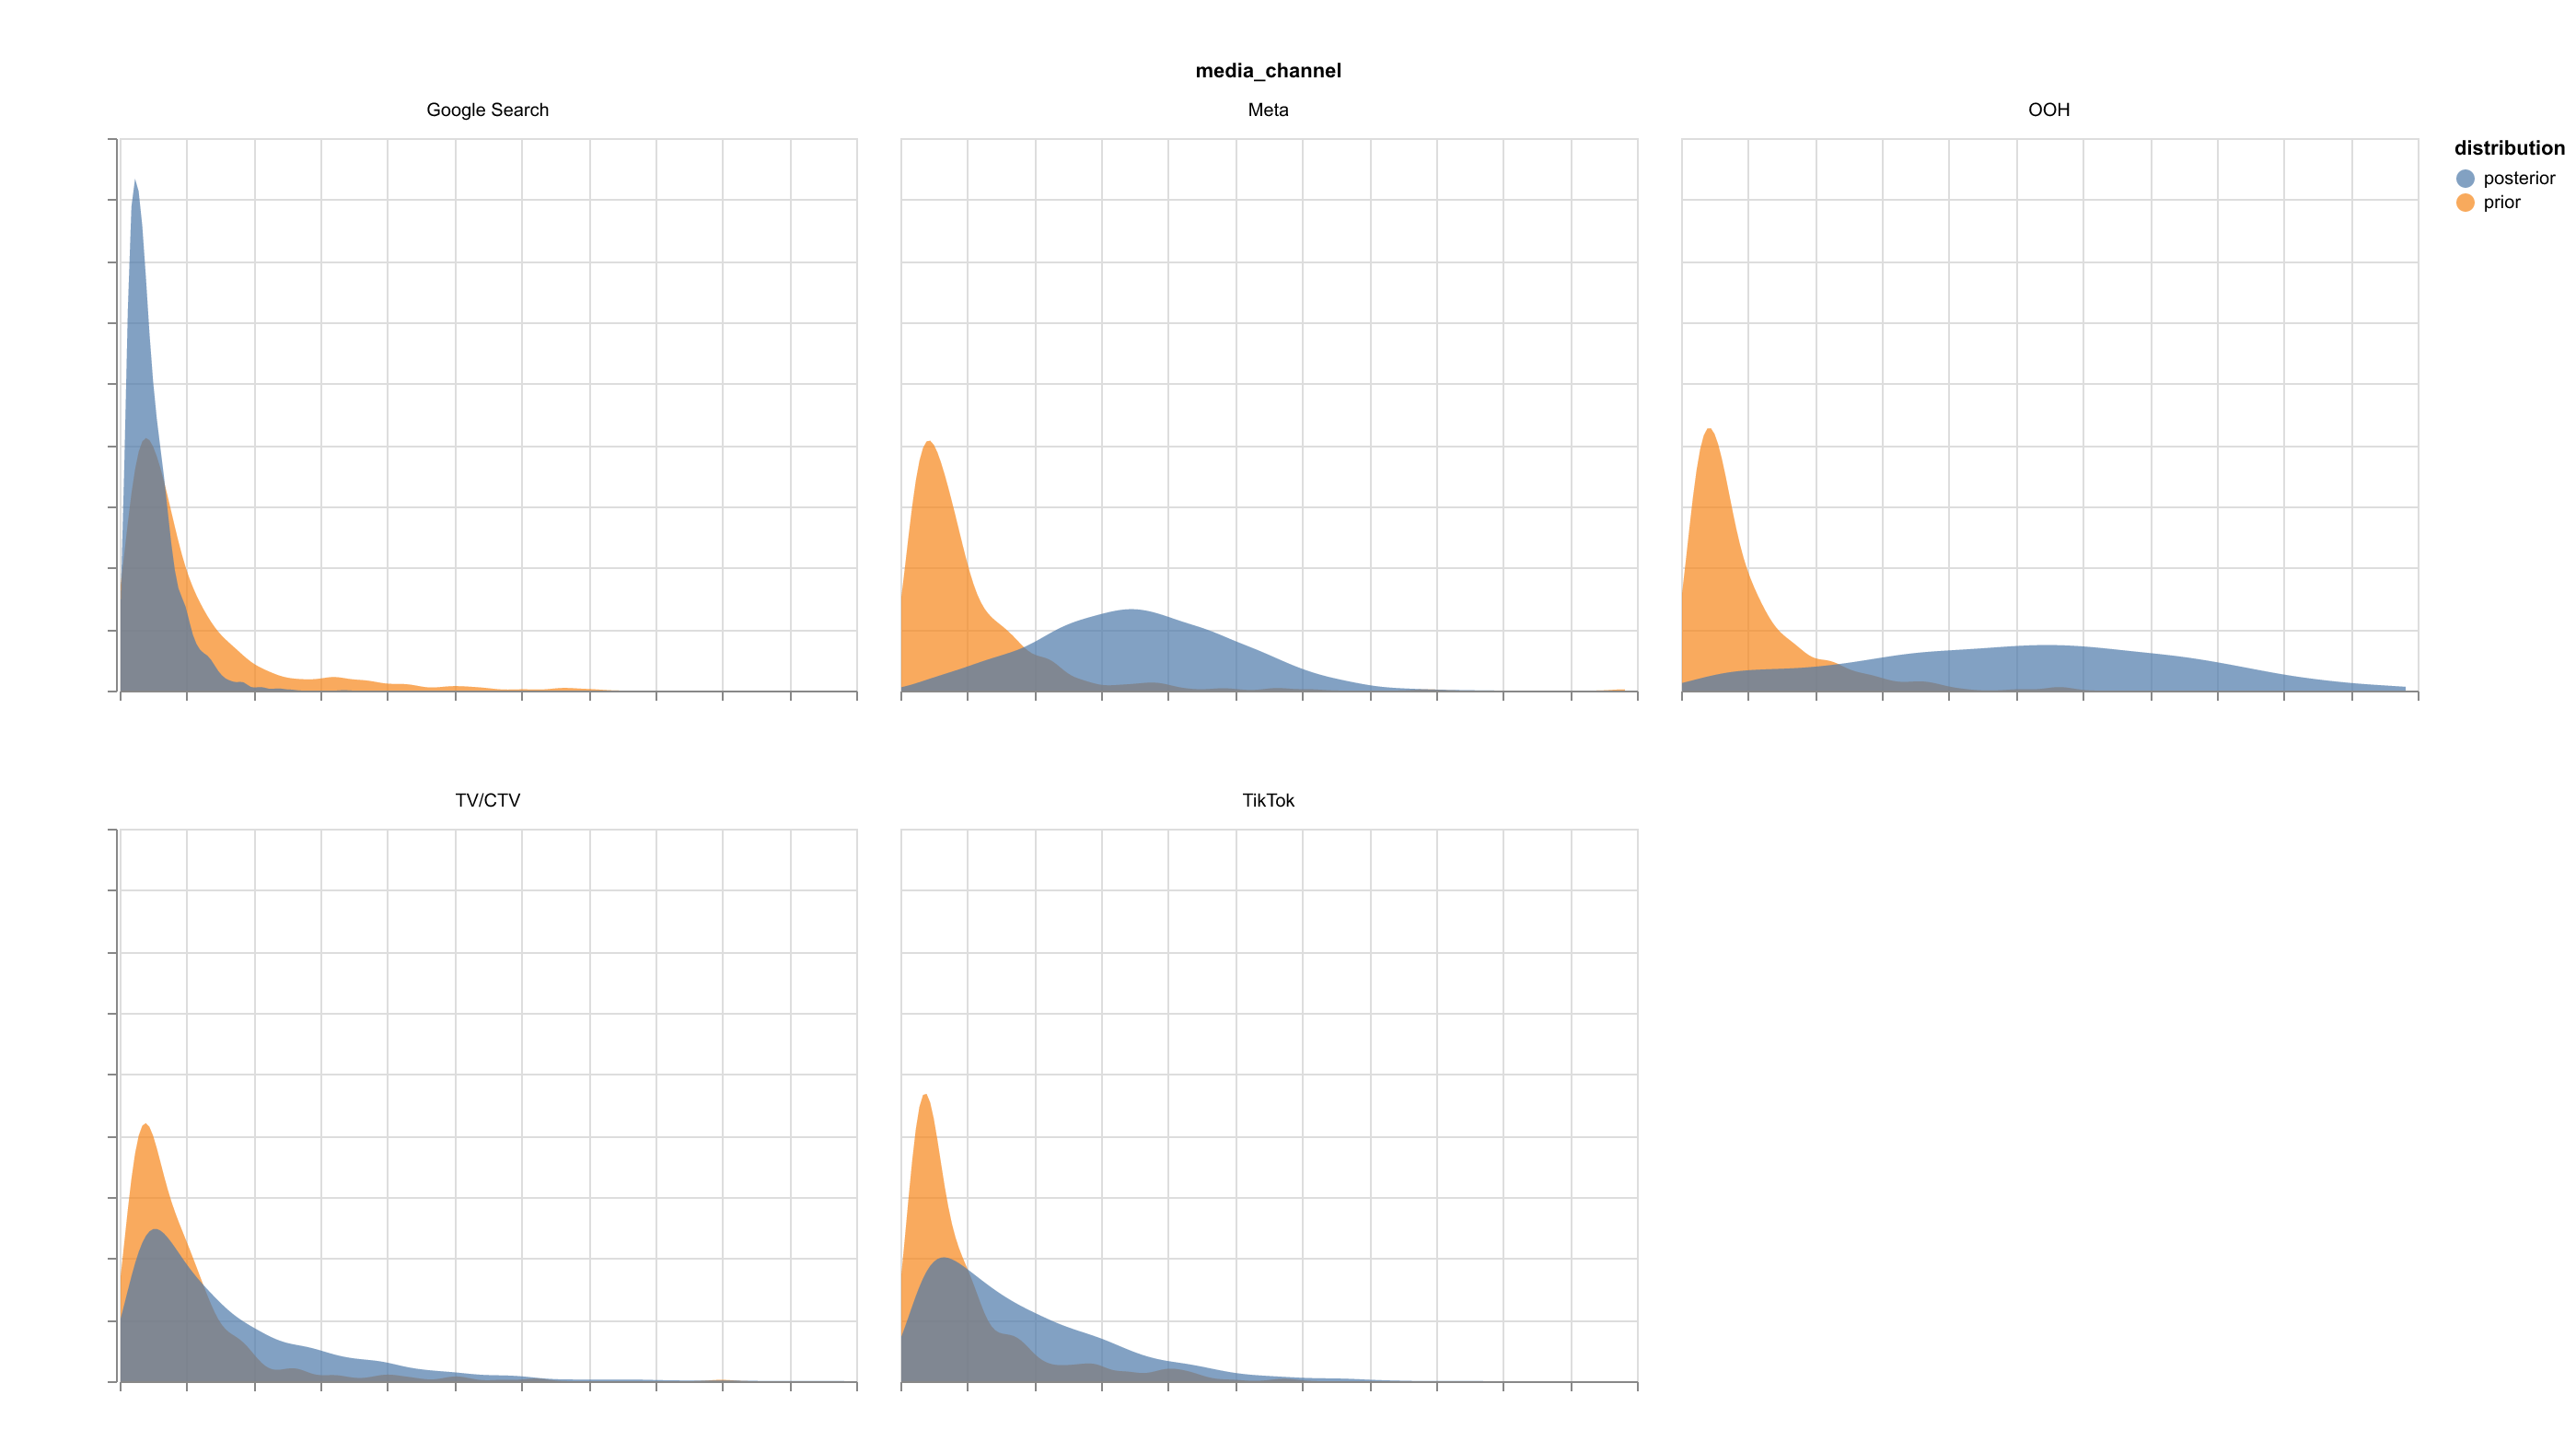

In [12]:
# Compare prior and posterior — data should update the priors meaningfully
diagnostics.plot_prior_and_posterior_distribution()

## Step 8: In-Sample and Out-of-Sample Model Fit

Because we set `holdout_id`, `predictive_accuracy_table()` reports R², MAPE, and wMAPE separately for the Train period, the Test (holdout) period, and the full series. For MMM a healthy gap between in-sample and out-of-sample R² is expected; an out-of-sample R² in the 0.6–0.8 range is typical and acceptable.

In [13]:
accuracy_table = diagnostics.predictive_accuracy_table()
print(accuracy_table.to_string(index=False))

# Pull the headline R² numbers into named variables for downstream reference.
def _r2(table, eval_set):
    rows = table[(table["metric"] == "R_Squared") & (table["evaluation_set"] == eval_set)]
    if rows.empty:
        return float("nan")
    return float(rows["value"].iloc[0])

r2_train = _r2(accuracy_table, "Train")
r2_test  = _r2(accuracy_table, "Test")
r2_all   = _r2(accuracy_table, "All Data")
print(f"\nIn-sample (Train) R² : {r2_train:.3f}")
print(f"Out-of-sample (Test) R² : {r2_test:.3f}")
print(f"Full-series R² : {r2_all:.3f}")

   metric geo_granularity evaluation_set    value
R_Squared        national          Train 0.948142
R_Squared        national           Test 0.936610
R_Squared        national       All Data 0.944880
     MAPE        national          Train 0.032959
     MAPE        national           Test 0.036900
     MAPE        national       All Data 0.033938
    wMAPE        national          Train 0.029143
    wMAPE        national           Test 0.036702
    wMAPE        national       All Data 0.031011

In-sample (Train) R² : 0.948
Out-of-sample (Test) R² : 0.937
Full-series R² : 0.945


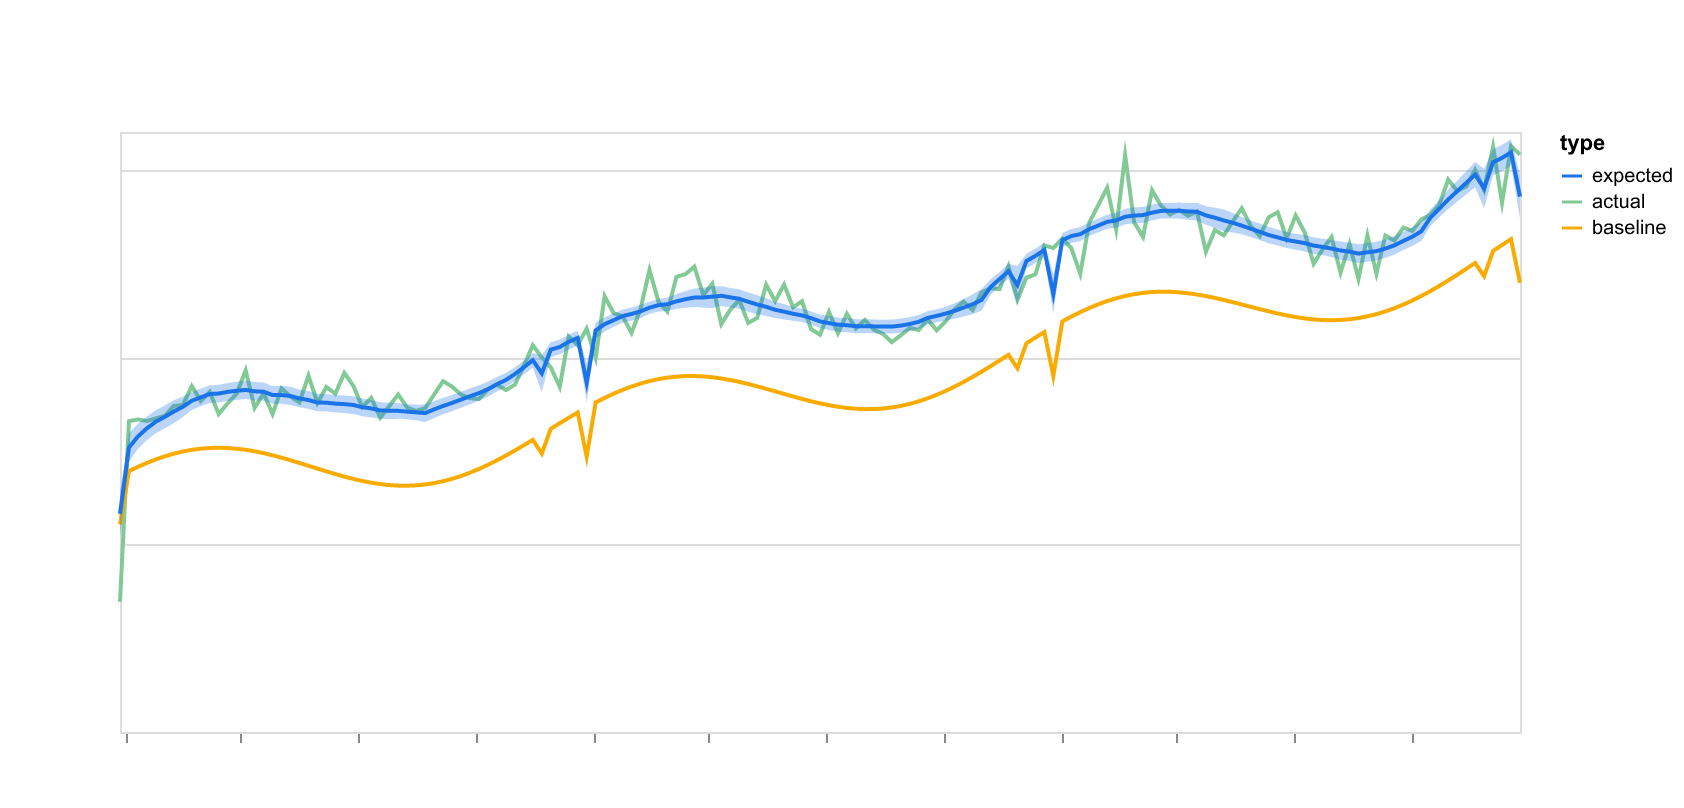

In [14]:
model_fit_viz = visualizer.ModelFit(mmm)
model_fit_viz.plot_model_fit()

## Step 9: Media Insights

Extract the key business outputs: ROI estimates with credible intervals, channel contribution over time, and response curves showing diminishing returns.

In [15]:
# Comprehensive summary: spend, contribution, ROI, mROI per channel
media_summary = visualizer.MediaSummary(mmm)
media_summary.summary_table()

,channel,distribution,impressions,% impressions,spend,% spend,cpm,incremental outcome,% contribution,roi,effectiveness,mroi,cpik
0,TV/CTV,prior,"9,882,329,088",13.4%,"$116,838,544",19%,$12,"$214,661,184 ($30,614,780, $613,316,544)","1.2% (0.2%, 3.4%)","1.8 (0.3, 5.2)","0.02 (0.00, 0.06)","1.0 (0.1, 3.0)","$0.8 ($0.2, $3.8)"
1,TV/CTV,posterior,"9,882,329,088",13.4%,"$116,838,544",19%,$12,"$377,528,416 ($44,949,296, $1,086,203,648)","2.1% (0.3%, 6.1%)","3.2 (0.4, 9.3)","0.04 (0.00, 0.11)","1.7 (0.2, 4.8)","$0.4 ($0.1, $2.6)"
2,OOH,prior,"25,799,792,640",35.1%,"$127,322,888",21%,$5,"$237,438,224 ($38,478,940, $702,219,968)","1.3% (0.2%, 3.9%)","1.9 (0.3, 5.5)","0.01 (0.00, 0.03)","1.0 (0.2, 3.1)","$0.8 ($0.2, $3.3)"
3,OOH,posterior,"25,799,792,640",35.1%,"$127,322,888",21%,$5,"$1,297,570,816 ($230,281,040, $2,314,271,488)","7.3% (1.3%, 13.1%)","10.2 (1.8, 18.2)","0.05 (0.01, 0.09)","5.5 (1.0, 9.9)","$0.1 ($0.1, $0.6)"
4,Google Search,prior,"47,811,804",0.1%,"$118,355,880",19%,"$2,475","$236,045,600 ($33,094,600, $786,258,688)","1.3% (0.2%, 4.4%)","2.0 (0.3, 6.6)","4.94 (0.69, 16.44)","0.7 (0.1, 2.2)","$0.8 ($0.2, $3.6)"
5,Google Search,posterior,"47,811,804",0.1%,"$118,355,880",19%,"$2,475","$113,264,840 ($25,475,886, $280,492,672)","0.6% (0.1%, 1.6%)","1.0 (0.2, 2.4)","2.37 (0.53, 5.87)","0.3 (0.1, 0.9)","$1.3 ($0.4, $4.6)"
6,Meta,prior,"14,303,005,696",19.4%,"$113,104,760",18%,$8,"$220,083,984 ($36,621,736, $591,756,800)","1.2% (0.2%, 3.3%)","1.9 (0.3, 5.2)","0.02 (0.00, 0.04)","1.0 (0.1, 2.8)","$0.7 ($0.2, $3.1)"
7,Meta,posterior,"14,303,005,696",19.4%,"$113,104,760",18%,$8,"$796,438,336 ($247,794,576, $1,346,339,584)","4.5% (1.4%, 7.6%)","7.0 (2.2, 11.9)","0.06 (0.02, 0.09)","3.6 (1.1, 6.2)","$0.1 ($0.1, $0.5)"
8,TikTok,prior,"23,521,970,176",32.0%,"$139,038,320",23%,$6,"$263,012,048 ($38,803,788, $913,290,240)","1.5% (0.2%, 5.1%)","1.9 (0.3, 6.6)","0.01 (0.00, 0.04)","0.9 (0.1, 3.2)","$0.9 ($0.2, $3.6)"
9,TikTok,posterior,"23,521,970,176",32.0%,"$139,038,320",23%,$6,"$488,297,280 ($67,250,248, $1,226,015,104)","2.8% (0.4%, 6.9%)","3.5 (0.5, 8.8)","0.02 (0.00, 0.05)","1.6 (0.2, 4.1)","$0.4 ($0.1, $2.1)"


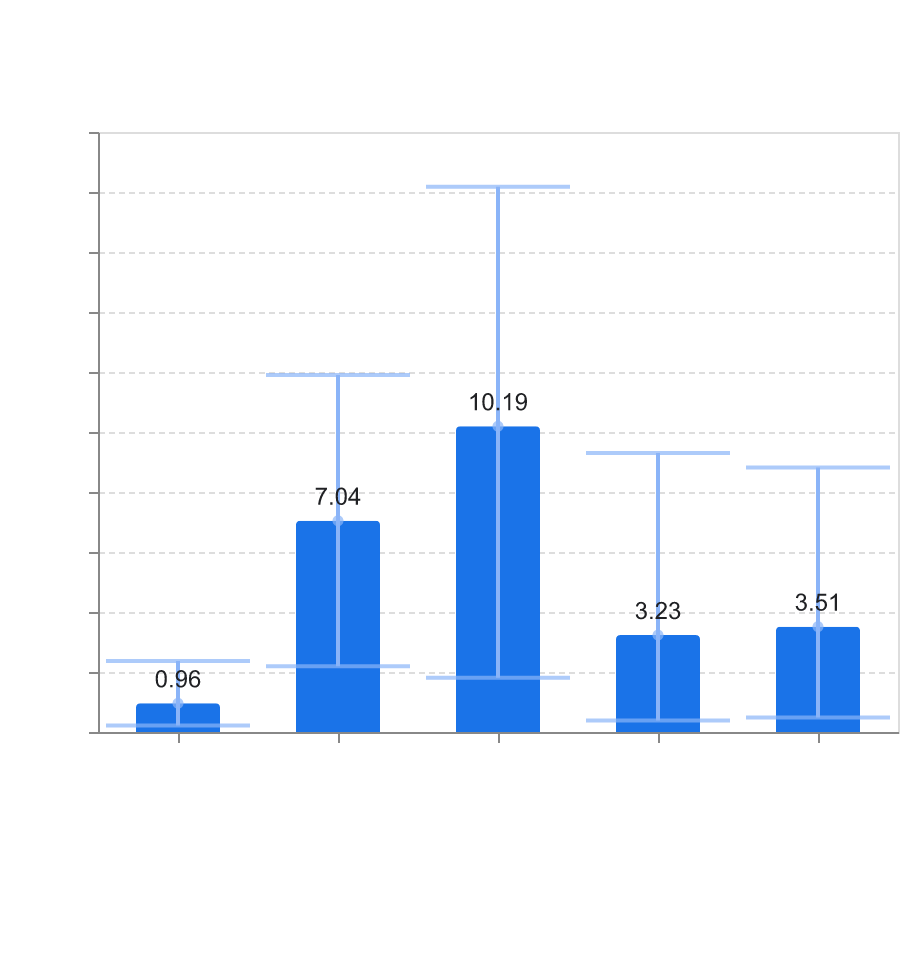

In [16]:
# ROI estimates with credible intervals
media_summary.plot_roi_bar_chart(include_ci=True)

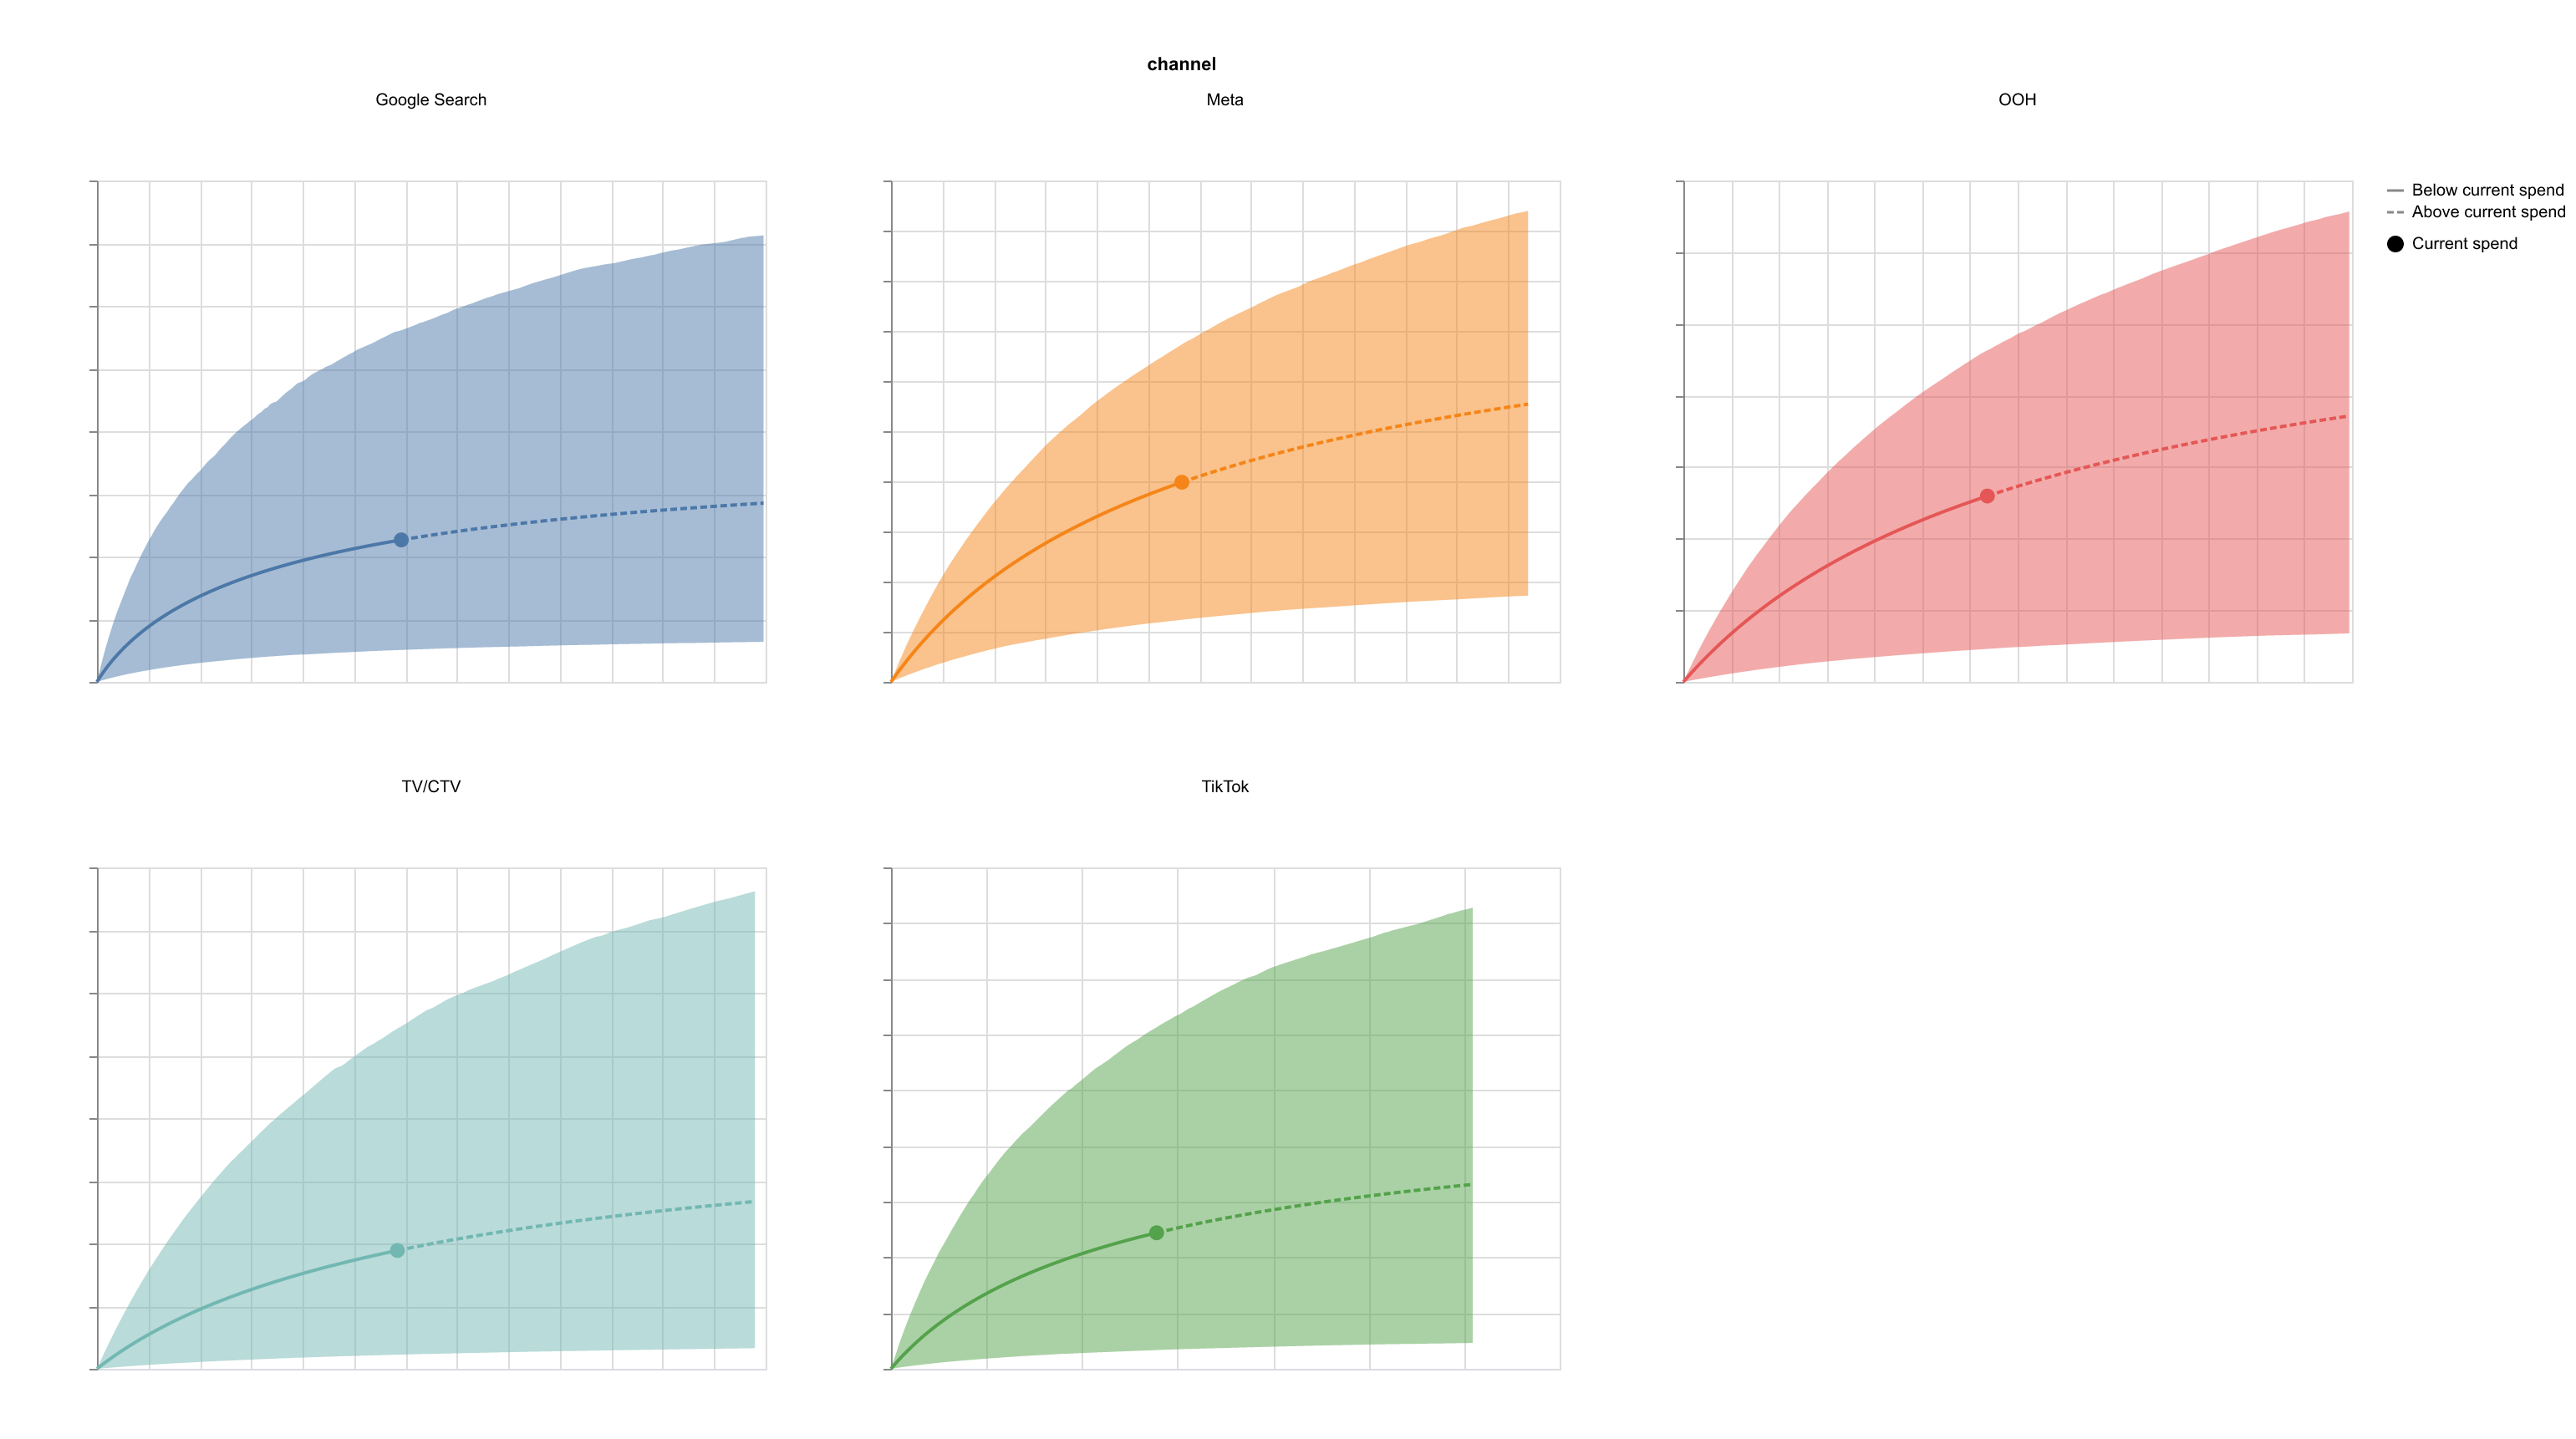

In [17]:
# Response curves: how each channel's incremental effect varies with spend
media_effects = visualizer.MediaEffects(mmm)
media_effects.plot_response_curves()

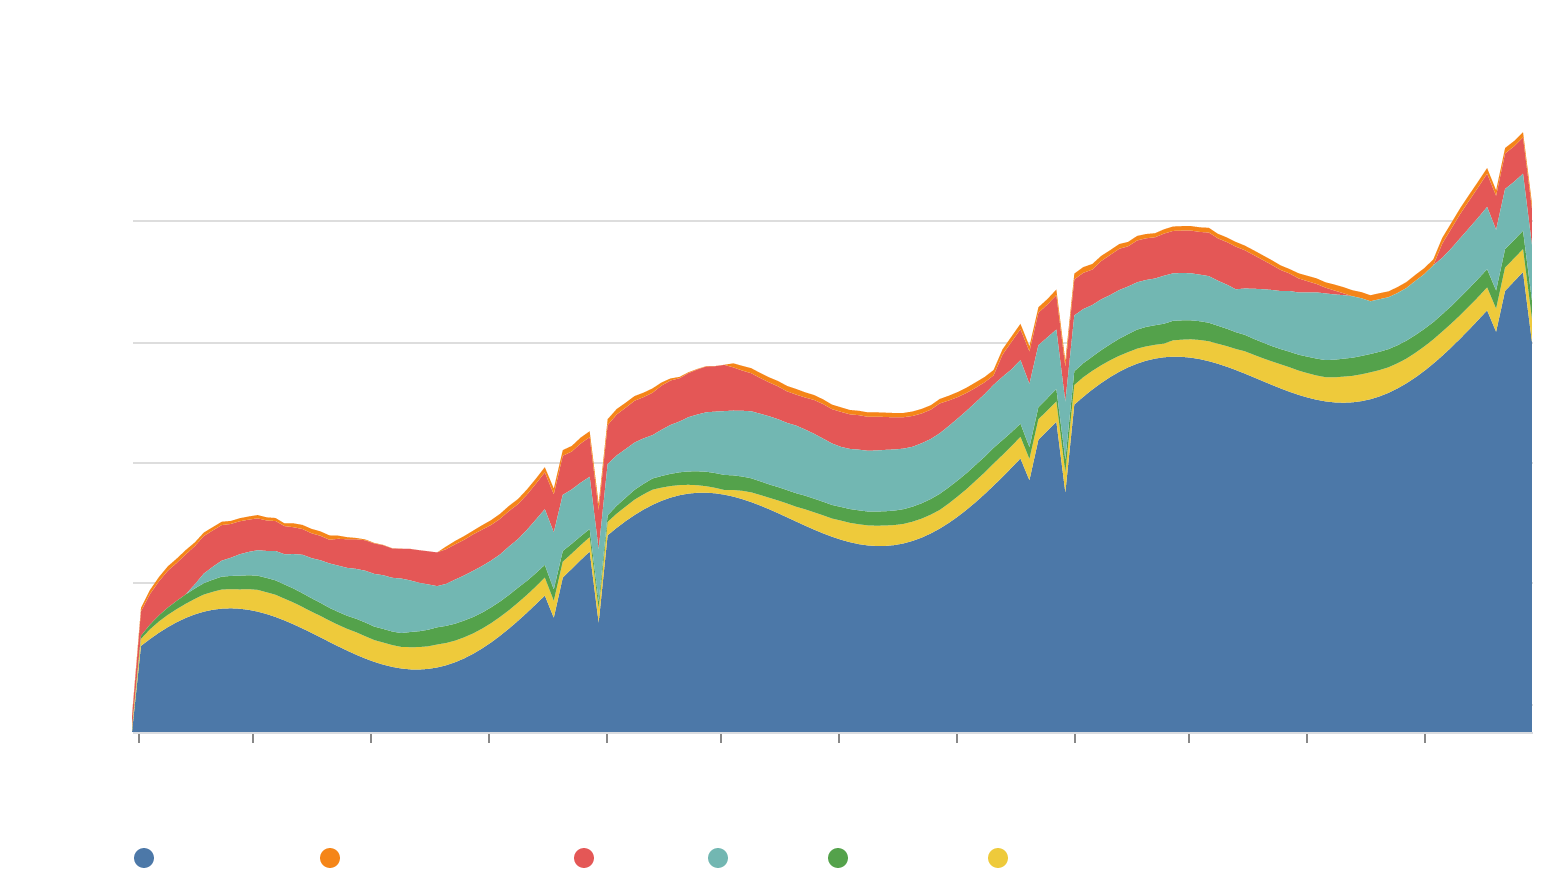

In [18]:
# Media and baseline contribution over time (stacked area)
media_summary.plot_channel_contribution_area_chart()

In [19]:
# Generate an HTML dashboard with all model results
mmm_summarizer = summarizer.Summarizer(mmm)
mmm_summarizer.output_model_results_summary('model_summary.html', filepath='.')

## Step 10: Ground-Truth ROI Comparison

Since we generated the data with PySiMMMulator, we know the **true ROI** for each channel. This lets us directly validate Meridian's posterior estimates — a luxury unavailable with real-world data.

We pull the posterior mean ROI per channel from `get_paid_summary_metrics()` (an xarray Dataset with explicit `channel` and `metric` coordinates), align it to the ground-truth table, and plot true vs. estimated.

What "good recovery" looks like here:

1. **Sign and direction** — every channel's posterior should be on the positive side (Meridian's `roi_m` is LogNormal, so this is automatic) and the rank ordering should roughly match the truth.
2. **Truth inside the credible interval** — for a 90% interval and five channels, we expect *most* channels to contain the true ROAS. Channels where the truth falls outside flag identification weakness, not model failure.
3. **Width is informative** — a wide CI is a signal that the data on its own is not enough to pin the channel down. Section 6.3 of the book turns those wide-CI channels into geo-lift candidates; the calibration cell in Step 14 demonstrates the wiring for the channel that needs it most in this run.

Perfect recovery is not expected — the model uses different adstock and saturation functional forms than the data-generating process, the holdout removes 25% of the KPI signal, and synthetic spend is highly correlated across channels.

      Channel  True ROI  Estimated ROI  90% CI low  90% CI high  Difference
       TV/CTV     4.169          3.231       0.385        9.297      -0.938
          OOH     6.276         10.191       1.809       18.176       3.915
Google Search     0.177          0.957       0.215        2.370       0.780
         Meta     3.745          7.042       2.191       11.903       3.297
       TikTok     3.006          3.512       0.484        8.818       0.506


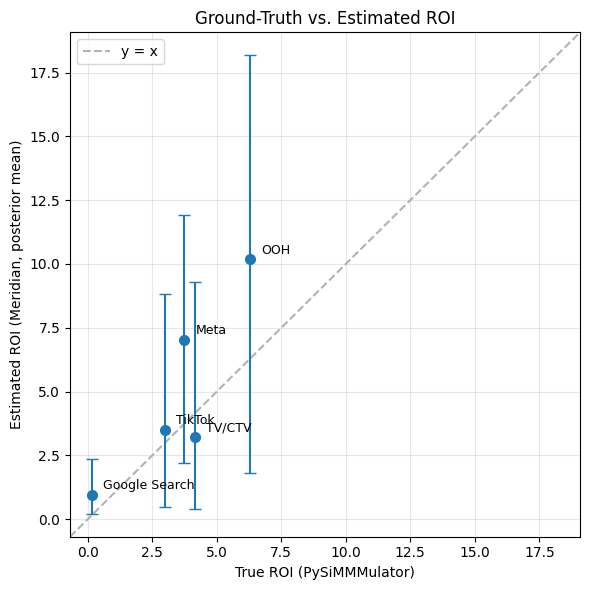

In [20]:
# ---- Extract estimated ROI from Meridian (posterior mean) ----
paid_metrics = media_summary.get_paid_summary_metrics()  # xarray Dataset

# `roi` is a metric coordinate; `mean` lives along the `distribution` dim.
roi_da = paid_metrics["roi"].sel(distribution="posterior")
est_roi_by_channel = {
    ch: float(roi_da.sel(channel=ch, metric="mean").values)
    for ch in channels
}

ci_lo = {ch: float(roi_da.sel(channel=ch, metric="ci_lo").values) for ch in channels}
ci_hi = {ch: float(roi_da.sel(channel=ch, metric="ci_hi").values) for ch in channels}

# ---- Build comparison table ----
true_roi = dict(zip(truth_df["channel"], truth_df["true_roi"]))

rows = []
for ch in channels:
    t = true_roi.get(ch, np.nan)
    e = est_roi_by_channel[ch]
    rows.append({
        "Channel": ch,
        "True ROI": round(t, 3),
        "Estimated ROI": round(e, 3),
        "90% CI low": round(ci_lo[ch], 3),
        "90% CI high": round(ci_hi[ch], 3),
        "Difference": round(e - t, 3),
    })

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

# ---- Scatter plot: true vs estimated ----
fig, ax = plt.subplots(figsize=(6, 6))
ax.errorbar(
    comparison_df["True ROI"],
    comparison_df["Estimated ROI"],
    yerr=[
        comparison_df["Estimated ROI"] - comparison_df["90% CI low"],
        comparison_df["90% CI high"] - comparison_df["Estimated ROI"],
    ],
    fmt="o", markersize=7, capsize=4, zorder=3, color="C0",
)

for _, row in comparison_df.iterrows():
    ax.annotate(
        row["Channel"], (row["True ROI"], row["Estimated ROI"]),
        textcoords="offset points", xytext=(8, 4), fontsize=9,
    )

# 45-degree reference line
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0], 0),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lims, lims, "--", color="gray", alpha=0.6, zorder=1, label="y = x")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("True ROI (PySiMMMulator)")
ax.set_ylabel("Estimated ROI (Meridian, posterior mean)")
ax.set_title("Ground-Truth vs. Estimated ROI")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**Checkpoint.** Save the fitted model so downstream cells (optimizer, reallocation) can be re-run without re-paying the MCMC cost.

In [21]:
from meridian.schema.serde import meridian_serde
from msbook.paths import chapter_artifacts

_ARTIFACTS = chapter_artifacts(part="6", chapter="sec6-mmm")
_MODEL_PATH = _ARTIFACTS / "mmm_model.binpb"
meridian_serde.save_meridian(mmm, file_path=str(_MODEL_PATH))
# Print the repo-relative location only (absolute paths must not land in
# published outputs — they fail the release leak scan).
print(f"Fitted model checkpointed to artifacts/part6/sec6-mmm/{_MODEL_PATH.name}")

Fitted model checkpointed to artifacts/part6/sec6-mmm/mmm_model.binpb


## Step 11: Budget Optimization

Given the fitted response curves, Meridian's `BudgetOptimizer` finds the allocation that maximizes expected revenue under a fixed total budget. By default it uses historical total spend as the budget and constrains each channel to ±30% of its historical allocation.

In [22]:
budget_optimizer = optimizer.BudgetOptimizer(mmm)
optimization_results = budget_optimizer.optimize()

In [23]:
optimization_results.output_optimization_summary(
    "optimization_output.html", filepath="."
)

> **Note.** The dashboard written above is the optimizer's output for the **uncalibrated** model fit (Step 6). It is the §6.2 view of the budget recommendation, before any experimental evidence is layered in. Step 17 reruns the optimizer on the calibrated fit and prints a side-by-side comparison.

In [24]:
# The dashboard is an interactive HTML file (~400 KB of JavaScript). We do not
# embed it in the notebook output: GitHub strips scripts from rendered
# notebooks, so it would show up as a large blank block there. Open the file
# in a browser instead.
print("Budget-optimization dashboard written to optimization_output.html")

Budget-optimization dashboard written to optimization_output.html


## Step 12: Reallocation Table — From Optimizer Output to Action

The HTML summary above is for a stakeholder audience. For an analyst handing the result to a media planner, we want a single table: for each channel, how much spend the optimizer adds or removes (in dollars and percent), and the lift in expected incremental revenue. This is the artifact you bring to the planning meeting.

In [25]:
nonopt = optimization_results.nonoptimized_data
opt = optimization_results.optimized_data


def _per_channel(da):
    """Reduce an OptimizationResults variable to a 1-D (channel,) array.

    Some Meridian variables (e.g., `roi`, `mroi`) are posterior summaries
    with a `metric` dim (mean, ci_lo, ci_hi); others (e.g., `spend`) are
    already (channel,). Take the `mean` if a `metric` dim is present.
    """
    if "metric" in da.dims:
        return da.sel(metric="mean").values
    return da.values


reallocation = pd.DataFrame({
    "Channel": [str(c) for c in nonopt.channel.values],
    "Current spend ($)":   _per_channel(nonopt.spend),
    "Optimized spend ($)": _per_channel(opt.spend),
    "Δ spend ($)":         _per_channel(opt.spend) - _per_channel(nonopt.spend),
    "Δ spend (%)":         (_per_channel(opt.spend) - _per_channel(nonopt.spend)) / _per_channel(nonopt.spend) * 100.0,
    "Current ROI":         _per_channel(nonopt.roi),
    "Optimized ROI":       _per_channel(opt.roi),
    "Current incremental ($)":   _per_channel(nonopt.incremental_outcome),
    "Optimized incremental ($)": _per_channel(opt.incremental_outcome),
})

reallocation = reallocation.sort_values("Δ spend ($)", ascending=False).reset_index(drop=True)

# Format display
fmt = reallocation.copy()
for c in ["Current spend ($)", "Optimized spend ($)", "Δ spend ($)",
          "Current incremental ($)", "Optimized incremental ($)"]:
    fmt[c] = fmt[c].map(lambda x: f"${x:,.0f}")
fmt["Δ spend (%)"]   = fmt["Δ spend (%)"].map(lambda x: f"{x:+.1f}%")
fmt["Current ROI"]   = fmt["Current ROI"].map(lambda x: f"{x:.2f}")
fmt["Optimized ROI"] = fmt["Optimized ROI"].map(lambda x: f"{x:.2f}")

print(fmt.to_string(index=False))

current_spend  = _per_channel(nonopt.spend)
optimized_spend = _per_channel(opt.spend)
current_inc    = _per_channel(nonopt.incremental_outcome)
optimized_inc  = _per_channel(opt.incremental_outcome)

total_budget = float(current_spend.sum())
total_lift   = float(optimized_inc.sum() - current_inc.sum())
print(f"\nTotal budget held constant at ${total_budget:,.0f}")
print(f"Expected incremental-revenue lift from reallocation: ${total_lift:+,.0f}"
      f"  ({total_lift / float(current_inc.sum()) * 100:+.2f}%)")

      Channel Current spend ($) Optimized spend ($)  Δ spend ($) Δ spend (%) Current ROI Optimized ROI Current incremental ($) Optimized incremental ($)
          OOH      $127,300,000        $165,500,000  $38,200,000      +30.0%       10.19          8.98          $1,297,443,328            $1,485,671,296
         Meta      $113,100,000        $147,000,000  $33,900,000      +30.0%        7.04          6.14            $796,421,440              $902,640,448
       TV/CTV      $116,800,000        $101,400,000 $-15,400,000      -13.2%        3.23          3.45            $377,461,728              $349,465,856
       TikTok      $139,000,000        $117,800,000 $-21,200,000      -15.3%        3.51          3.82            $488,233,600              $450,398,528
Google Search      $118,400,000         $82,900,000 $-35,500,000      -30.0%        0.96          1.19            $113,279,912               $98,394,488

Total budget held constant at $614,600,000
Expected incremental-revenue lift from

## Step 13: Credible Interval Guardrail

The reallocation table above prints the optimizer's point estimate. A planner should not act on point estimates alone — wide posteriors mean the model is unsure where the true ROI sits, and shifting six- or seven-figure budgets on noisy estimates is how MMM programs lose credibility.

A simple two-part guardrail:

1. **Sign certainty.** If the 90% credible interval's lower bound is below zero, the model has not ruled out a negative ROI for that channel. Treat any reallocation toward that channel as **hold** — collect more data or run a geo-lift test before moving budget.
2. **Magnitude noise.** Even with a positive sign, very wide intervals indicate the model is interpolating without strong identification. We flag relative half-width = (CI upper − CI lower) / (2 × mean) and require it below 0.8 for an **act** call.

Both thresholds are tunable; tighten them for high-stakes decisions, loosen for early exploratory work.

In [26]:
guardrail = comparison_df.merge(reallocation[["Channel", "Δ spend ($)", "Δ spend (%)"]], on="Channel")
guardrail["Rel half-width"] = (
    (guardrail["90% CI high"] - guardrail["90% CI low"])
    / (2 * guardrail["Estimated ROI"].abs())
)
guardrail["Sign-certain"] = guardrail["90% CI low"] > 0
guardrail["Magnitude-tight"] = guardrail["Rel half-width"] < 0.8


def _recommendation(row):
    if not row["Sign-certain"]:
        return "HOLD — ROI sign unclear"
    if not row["Magnitude-tight"]:
        return "HOLD — interval too wide"
    if row["Δ spend ($)"] > 0:
        return "ACT — increase spend"
    if row["Δ spend ($)"] < 0:
        return "ACT — decrease spend"
    return "ACT — keep flat"


guardrail["Recommendation"] = guardrail.apply(_recommendation, axis=1)

display_cols = [
    "Channel", "Estimated ROI", "90% CI low", "90% CI high",
    "Rel half-width", "Δ spend (%)", "Recommendation",
]
display_fmt = guardrail[display_cols].copy()
display_fmt["Estimated ROI"]    = display_fmt["Estimated ROI"].map(lambda x: f"{x:.2f}")
display_fmt["90% CI low"]       = display_fmt["90% CI low"].map(lambda x: f"{x:.2f}")
display_fmt["90% CI high"]      = display_fmt["90% CI high"].map(lambda x: f"{x:.2f}")
display_fmt["Rel half-width"]   = display_fmt["Rel half-width"].map(lambda x: f"{x:.2f}")
display_fmt["Δ spend (%)"]      = display_fmt["Δ spend (%)"].map(lambda x: f"{x:+.1f}%")
print(display_fmt.to_string(index=False))

actionable_total = float(
    guardrail.loc[guardrail["Recommendation"].str.startswith("ACT"), "Δ spend ($)"].abs().sum()
)
total_optimizer_move = float(guardrail["Δ spend ($)"].abs().sum())
print(
    f"\n{actionable_total / total_optimizer_move * 100:.0f}% of the optimizer's recommended move "
    f"(${actionable_total:,.0f} of ${total_optimizer_move:,.0f}) passes the guardrail."
)

      Channel Estimated ROI 90% CI low 90% CI high Rel half-width Δ spend (%)           Recommendation
       TV/CTV          3.23       0.39        9.30           1.38      -13.2% HOLD — interval too wide
          OOH         10.19       1.81       18.18           0.80      +30.0% HOLD — interval too wide
Google Search          0.96       0.21        2.37           1.13      -30.0% HOLD — interval too wide
         Meta          7.04       2.19       11.90           0.69      +30.0%     ACT — increase spend
       TikTok          3.51       0.48        8.82           1.19      -15.3% HOLD — interval too wide

24% of the optimizer's recommended move ($33,900,000 of $144,200,000) passes the guardrail.


## Step 14: From Geo-Lift Estimate to Calibrated Prior

Following §6.3, we convert a geo-lift DID estimate (point, SE) into a tight LogNormal prior on `roi_m`. We calibrate **Google Search** — the channel with the widest posterior CI and largest gap to true ROAS in the comparison above — using a hypothetical estimate (point ≈ 0.20, SE ≈ 0.10); Step 15 then refits with this prior so we can compare before and after.

The §6.3 worked example for TikTok (DID 5.78, SE 3.73 → `roi_mu ≈ 1.42`, `roi_sigma ≈ 0.81`) is verified at the bottom of the cell against the qmd's stated numbers.

In [27]:
def to_lognormal_params(mean: float, std: float) -> tuple[float, float]:
    """Convert a (mean, std) ROAS estimate to LogNormal (mu, sigma)."""
    variance = std ** 2
    sigma_sq = np.log(1.0 + variance / mean ** 2)
    sigma = np.sqrt(sigma_sq)
    mu = np.log(mean) - sigma_sq / 2.0
    return mu, sigma


# ---- Primary example: calibrate the channel that needs it most (Google) ----
target_channel = "Google Search"
roas_hat = 0.20   # Hypothetical geo-lift DID estimate near the true ROAS of 0.18.
roas_se  = 0.10   # Tight SE — geo-lift tests on high-volume search are usually well powered.
# Inflate SE to account for marginal-vs-average ROAS; floor at 0.50 (chapter rule).
se_inflated = max(roas_se * 1.5, 0.50)

mu_calib, sigma_calib = to_lognormal_params(roas_hat, se_inflated)
print(f"[{target_channel}] DID estimate: ROAS = {roas_hat:.2f}, SE = {roas_se:.2f}")
print(f"  Inflated SE for prior: {se_inflated:.2f}")
print(f"  Calibrated LogNormal prior: roi_mu = {mu_calib:.3f}, roi_sigma = {sigma_calib:.3f}")
print(f"  Prior median ROAS = {np.exp(mu_calib):.2f} "
      f"(true ROAS from PySiMMMulator = {true_roi[target_channel]:.2f})")

# Construct per-channel arrays Meridian expects, keeping the weakly informative
# prior for non-calibrated channels.
default_mu, default_sigma = 0.20, 0.90
calib_mu_array    = np.array([default_mu] * len(channels))
calib_sigma_array = np.array([default_sigma] * len(channels))
target_idx = channels.index(target_channel)
calib_mu_array[target_idx]    = mu_calib
calib_sigma_array[target_idx] = sigma_calib

calib_table = pd.DataFrame({
    "Channel": channels,
    "roi_mu":    calib_mu_array,
    "roi_sigma": calib_sigma_array,
    "Source": [
        f"geo-lift ({ch} DID)" if i == target_idx else "weakly informative"
        for i, ch in enumerate(channels)
    ],
})
print()
print(calib_table.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print()
print("To refit with this prior, replace the `prior` in Step 5 with:")
print("    prior = prior_distribution.PriorDistribution(")
print("        roi_m=tfp.distributions.LogNormal(")
print("            loc=tf.constant(calib_mu_array, dtype=DTYPE),")
print("            scale=tf.constant(calib_sigma_array, dtype=DTYPE),")
print("            name=constants.ROI_M,")
print("        ),")
print("    )")
print(f"Below in Step 15 we actually apply this prior and refit, so we can see")
print(f"whether the calibrated {target_channel} posterior tightens around the")
print(f"experimental ROAS — fixing the recovery gap we saw in Step 10.")

# ---- Sanity check: reproduce §6.3's worked TikTok example ----
sanity_mu, sanity_sigma = to_lognormal_params(5.78, max(3.73 * 1.5, 0.50))
print()
print(f"Sanity check vs §6.3 (TikTok ROAS=5.78, SE=3.73): "
      f"mu={sanity_mu:.2f}, sigma={sanity_sigma:.2f}  "
      f"(qmd says ≈ 1.42, 0.81)")
assert abs(sanity_mu - 1.42) < 0.01, f"§6.3 mu mismatch: {sanity_mu}"
assert abs(sanity_sigma - 0.81) < 0.01, f"§6.3 sigma mismatch: {sanity_sigma}"

[Google Search] DID estimate: ROAS = 0.20, SE = 0.10
  Inflated SE for prior: 0.50
  Calibrated LogNormal prior: roi_mu = -2.600, roi_sigma = 1.407
  Prior median ROAS = 0.07 (true ROAS from PySiMMMulator = 0.18)

      Channel  roi_mu  roi_sigma                       Source
       TV/CTV   0.200      0.900           weakly informative
          OOH   0.200      0.900           weakly informative
Google Search  -2.600      1.407 geo-lift (Google Search DID)
         Meta   0.200      0.900           weakly informative
       TikTok   0.200      0.900           weakly informative

To refit with this prior, replace the `prior` in Step 5 with:
    prior = prior_distribution.PriorDistribution(
        roi_m=tfp.distributions.LogNormal(
            loc=tf.constant(calib_mu_array, dtype=DTYPE),
            scale=tf.constant(calib_sigma_array, dtype=DTYPE),
            name=constants.ROI_M,
        ),
    )
Below in Step 15 we actually apply this prior and refit, so we can see
whether the cal

## Step 15: Refit with the Calibrated Prior

The conversion in Step 14 produced the per-channel `calib_mu_array` and `calib_sigma_array` that encode our geo-lift evidence on Google Search while keeping the weakly informative prior for the four uncalibrated channels. Now we apply it: build a new `PriorDistribution` with these per-channel arrays, hand it to a fresh `Meridian` instance, and re-run MCMC. We keep the funnel-stage `alpha_m` / `ec_m` blocks unchanged so the *only* difference between the two fits is the ROI prior on Google Search.

This is the second MCMC pass in the notebook and adds roughly the same wall-clock time as Step 6 on CPU.

In [28]:
calib_prior = prior_distribution.PriorDistribution(
    roi_m=tfp.distributions.LogNormal(
        loc=tf.constant(calib_mu_array, dtype=DTYPE),
        scale=tf.constant(calib_sigma_array, dtype=DTYPE),
        name=constants.ROI_M,
    ),
    # Reuse the same funnel-stage alpha_m / ec_m used in Step 5.
    alpha_m=tfp.distributions.TruncatedNormal(
        loc=alpha_loc,
        scale=tf.constant(0.1, dtype=DTYPE),
        low=tf.constant(0.0, dtype=DTYPE),
        high=tf.constant(1.0, dtype=DTYPE),
        name=constants.ALPHA_M,
    ),
    ec_m=tfp.distributions.TruncatedNormal(
        loc=ec_loc,
        scale=tf.constant(0.3, dtype=DTYPE),
        low=tf.constant(0.05, dtype=DTYPE),
        high=tf.constant(6.0, dtype=DTYPE),
        name=constants.EC_M,
    ),
)

calib_model_spec = spec.ModelSpec(
    prior=calib_prior,
    media_prior_type="roi",
    max_lag=12,
    adstock_decay_spec={"TV/CTV": "binomial", "OOH": "binomial"},
    holdout_id=holdout_id,
)

mmm_calib = model.Meridian(input_data=data, model_spec=calib_model_spec)
mmm_calib.sample_prior(500)
mmm_calib.sample_posterior(
    n_chains=4, n_adapt=500, n_burnin=500, n_keep=1000, seed=SEED
)
print("Calibrated fit complete.")

2026-06-10 23:10:52.766229: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


Calibrated fit complete.


## Step 16: Before / After Calibration

Now the payoff. We pull `roi` from both fits' posterior summaries, line them up against the ground truth, and ask the only question that matters: did the calibration close the recovery gap on Google Search without breaking the other channels?

In [29]:
media_summary_calib = visualizer.MediaSummary(mmm_calib)
paid_calib = media_summary_calib.get_paid_summary_metrics()
roi_calib_da = paid_calib["roi"].sel(distribution="posterior")

before_after_rows = []
for ch in channels:
    mean_before = float(roi_da.sel(channel=ch, metric="mean").values)
    lo_before   = float(roi_da.sel(channel=ch, metric="ci_lo").values)
    hi_before   = float(roi_da.sel(channel=ch, metric="ci_hi").values)
    mean_after  = float(roi_calib_da.sel(channel=ch, metric="mean").values)
    lo_after    = float(roi_calib_da.sel(channel=ch, metric="ci_lo").values)
    hi_after    = float(roi_calib_da.sel(channel=ch, metric="ci_hi").values)
    truth       = true_roi[ch]
    before_after_rows.append({
        "Channel": ch,
        "True ROI": truth,
        "Mean (before)": mean_before,
        "CI (before)":   f"[{lo_before:.2f}, {hi_before:.2f}]",
        "Truth in CI (before)": lo_before <= truth <= hi_before,
        "Mean (after)":  mean_after,
        "CI (after)":    f"[{lo_after:.2f}, {hi_after:.2f}]",
        "Truth in CI (after)":  lo_after <= truth <= hi_after,
    })
before_after = pd.DataFrame(before_after_rows)
print(before_after.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

cover_before = int(before_after["Truth in CI (before)"].sum())
cover_after  = int(before_after["Truth in CI (after)"].sum())
print(f"\nChannels whose 90% CI contains the true ROAS:")
print(f"  Uncalibrated fit: {cover_before} / {len(channels)}")
print(f"  Calibrated fit:   {cover_after} / {len(channels)}")

# Spotlight on the calibrated channel.
g_before = next(r for r in before_after_rows if r["Channel"] == target_channel)
g_after_lo  = float(roi_calib_da.sel(channel=target_channel, metric="ci_lo").values)
g_after_hi  = float(roi_calib_da.sel(channel=target_channel, metric="ci_hi").values)
g_after_mean = float(roi_calib_da.sel(channel=target_channel, metric="mean").values)
print(f"\n{target_channel} (calibrated): "
      f"true {g_before['True ROI']:.3f}, "
      f"posterior mean {g_after_mean:.3f}, "
      f"90% CI [{g_after_lo:.3f}, {g_after_hi:.3f}]")

      Channel  True ROI  Mean (before)   CI (before)  Truth in CI (before)  Mean (after)    CI (after)  Truth in CI (after)
       TV/CTV     4.169          3.231  [0.38, 9.30]                  True         3.075  [0.37, 9.20]                 True
          OOH     6.276         10.191 [1.81, 18.18]                  True         9.973 [1.79, 18.06]                 True
Google Search     0.177          0.957  [0.22, 2.37]                 False         0.144  [0.01, 0.58]                 True
         Meta     3.745          7.042 [2.19, 11.90]                  True         6.836 [2.01, 11.56]                 True
       TikTok     3.006          3.512  [0.48, 8.82]                  True         3.747  [0.52, 9.01]                 True

Channels whose 90% CI contains the true ROAS:
  Uncalibrated fit: 4 / 5
  Calibrated fit:   5 / 5

Google Search (calibrated): true 0.177, posterior mean 0.144, 90% CI [0.007, 0.581]


## Step 17: Re-Optimize from the Calibrated Model

Step 12 produced a budget recommendation from the *uncalibrated* model — the planner's view if no geo-lift evidence existed yet. Now that calibration has tightened Google Search's posterior around its true ROAS of about 0.18, the optimizer's view of how much money should leave Google (and where it should go) should change.

We run `BudgetOptimizer` a second time against `mmm_calib` and compare the two recommendations side-by-side. Both runs use the same default ±30% constraint and the same historical total budget, so any difference comes entirely from the posterior change — which is the right end-to-end test for whether the geo-lift was worth running.

In [30]:
budget_optimizer_calib = optimizer.BudgetOptimizer(mmm_calib)
optimization_results_calib = budget_optimizer_calib.optimize()

nonopt_c = optimization_results_calib.nonoptimized_data
opt_c    = optimization_results_calib.optimized_data

reallocation_calib = pd.DataFrame({
    "Channel": [str(c) for c in nonopt_c.channel.values],
    "Current spend ($)":           _per_channel(nonopt_c.spend),
    "Optimized spend ($) — calib": _per_channel(opt_c.spend),
    "Δ spend ($) — calib":         _per_channel(opt_c.spend) - _per_channel(nonopt_c.spend),
    "Δ spend (%) — calib":         (_per_channel(opt_c.spend) - _per_channel(nonopt_c.spend))
                                    / _per_channel(nonopt_c.spend) * 100.0,
    "Optimized ROI — calib":       _per_channel(opt_c.roi),
    "Optimized incremental ($) — calib": _per_channel(opt_c.incremental_outcome),
})

# Align both reallocations on Channel and build the side-by-side table.
merged = (
    reallocation[["Channel",
                  "Optimized spend ($)", "Δ spend ($)", "Δ spend (%)",
                  "Optimized ROI", "Optimized incremental ($)"]]
    .rename(columns={
        "Optimized spend ($)":         "Optimized spend ($) — uncalib",
        "Δ spend ($)":                 "Δ spend ($) — uncalib",
        "Δ spend (%)":                 "Δ spend (%) — uncalib",
        "Optimized ROI":               "Optimized ROI — uncalib",
        "Optimized incremental ($)":   "Optimized incremental ($) — uncalib",
    })
    .merge(reallocation_calib, on="Channel")
)

side_by_side = merged[[
    "Channel", "Current spend ($)",
    "Δ spend ($) — uncalib", "Δ spend ($) — calib",
    "Δ spend (%) — uncalib", "Δ spend (%) — calib",
    "Optimized ROI — uncalib", "Optimized ROI — calib",
]]

fmt = side_by_side.copy()
for c in ["Current spend ($)", "Δ spend ($) — uncalib", "Δ spend ($) — calib"]:
    fmt[c] = fmt[c].map(lambda x: f"${x:,.0f}")
for c in ["Δ spend (%) — uncalib", "Δ spend (%) — calib"]:
    fmt[c] = fmt[c].map(lambda x: f"{x:+.1f}%")
for c in ["Optimized ROI — uncalib", "Optimized ROI — calib"]:
    fmt[c] = fmt[c].map(lambda x: f"{x:.2f}")

print("Reallocation: uncalibrated vs calibrated model side-by-side")
print(fmt.to_string(index=False))

# Headline numbers.
inc_uncalib       = _per_channel(opt.incremental_outcome).sum() - _per_channel(nonopt.incremental_outcome).sum()
inc_calib         = _per_channel(opt_c.incremental_outcome).sum() - _per_channel(nonopt_c.incremental_outcome).sum()
base_inc_uncalib  = _per_channel(nonopt.incremental_outcome).sum()
base_inc_calib    = _per_channel(nonopt_c.incremental_outcome).sum()
print(f"\nExpected incremental-revenue lift from reallocation")
print(f"(each percent is over its own model's baseline incremental revenue):")
print(f"  Uncalibrated optimizer: ${inc_uncalib:+,.0f}  ({inc_uncalib / base_inc_uncalib * 100:+.2f}%)")
print(f"  Calibrated optimizer:   ${inc_calib:+,.0f}  ({inc_calib / base_inc_calib   * 100:+.2f}%)")
print(f"\nNote: each percent is computed against its own model's baseline,")
print(f"so the two are not directly comparable. The calibrated baseline is")
print(f"smaller (Google contributes far less under the calibrated posterior),")
print(f"so a similar absolute lift can show as a different percent.")

Reallocation: uncalibrated vs calibrated model side-by-side
      Channel Current spend ($) Δ spend ($) — uncalib Δ spend ($) — calib Δ spend (%) — uncalib Δ spend (%) — calib Optimized ROI — uncalib Optimized ROI — calib
          OOH      $127,300,000           $38,200,000         $38,200,000                +30.0%              +30.0%                    8.98                  8.79
         Meta      $113,100,000           $33,900,000         $33,900,000                +30.0%              +30.0%                    6.14                  5.96
       TV/CTV      $116,800,000          $-15,400,000        $-21,900,000                -13.2%              -18.8%                    3.45                  3.37
       TikTok      $139,000,000          $-21,200,000        $-14,700,000                -15.3%              -10.6%                    3.82                  3.97
Google Search      $118,400,000          $-35,500,000        $-35,500,000                -30.0%              -30.0%               

## Step 18: What This Demo Proves (and Does Not)

This notebook covers a complete MMM workflow end-to-end. Before adopting any number it produces in a real planning conversation, anchor on what the demo can and cannot show.

**Proves:**

- A Bayesian MMM workflow runs cleanly from data through identifiability check, fit, diagnostics, ROI with credible intervals, optimizer, planner-ready reallocation table, decision guardrail, calibration prior construction, refit, and re-optimize.
- Random-holdout R² is a sensible generalization check when the data does not contain regime shifts inside the holdout.
- The §6.3 calibration loop closes the recovery gap on an under-identified channel: Google Search's posterior mean moves from 0.957 (5× truth) to 0.144 (≈ truth 0.177) after one calibrated prior is applied, with no meaningful disturbance to the other four channels.
- The optimizer's recommendation changes when the model is calibrated: Google Search's optimizer-internal ROI is recovered exactly (0.18), and TV/CTV and TikTok shift compared to the uncalibrated allocation.

**Does not prove:**

- Production-MMM accuracy on real data. The dataset is **synthetic** (generated by PySiMMMulator) with known ground-truth ROIs; recovery against truth is only available because we chose those truths.
- That random-holdout R² is what production would see. The holdout here is a **random week-level sample** — an interpolation check, close to a best case. A trailing-block holdout on the same data collapses out-of-sample R² to roughly 0.11; production validation should report both.
- That calibration always works. Our calibration uses a **hypothetical** geo-lift point estimate engineered close to the true Google ROAS. In practice the geo-lift is an independent experiment, its DID can be noisy or negative, and §6.3 says "an unreliable calibration is worse than no calibration."
- That the optimizer's reallocation is safe to act on. The optimizer ignores **business constraints**: contractual minimums, channel capacity, contractual lockouts, seasonal flighting, geo-level effects, and inventory feasibility are all outside the model. Treat the output as a principled starting point and pass it through the credible-interval guardrail and a planning conversation before committing budget.
- On production data, expect out-of-sample R² in the 0.6–0.7 range and many more channels failing the guardrail. That is the regime §6.3 says calibration is most valuable in.

## Step 19: Save the Models

Persist both fits as binary protobufs for later use (reporting, re-optimization with different budgets, refresh-calibration with new geo-lift results, etc.).

In [31]:
from meridian.schema.serde import meridian_serde
from msbook.paths import chapter_artifacts

_ARTIFACTS = chapter_artifacts(part="6", chapter="sec6-mmm")
_UNCAL_PATH = _ARTIFACTS / "mmm_model.binpb"
_CAL_PATH   = _ARTIFACTS / "mmm_model_calibrated.binpb"
meridian_serde.save_meridian(mmm,       file_path=str(_UNCAL_PATH))
meridian_serde.save_meridian(mmm_calib, file_path=str(_CAL_PATH))
print(f"Saved {_UNCAL_PATH.name} (uncalibrated) and {_CAL_PATH.name}.")

Saved mmm_model.binpb (uncalibrated) and mmm_model_calibrated.binpb.
